# 11 — Loading & Inspecting Posterior Results

Load a completed inference run and visualize the posterior signal reconstruction.

**Prerequisites:** Run `astroprism-run --config ../configs/jwst_miri_4band.yaml` first.

In [11]:
from astroprism.io import PosteriorResult

result = PosteriorResult("../output/jwst_miri_tutorial")
print("Channels:", result.derived["channel_keys"])
print("Signal shape:", result.derived["signal_shape"])

Channels: ['F1000W_full', 'F1130W_full', 'F2100W_full', 'F770W_full']
Signal shape: [600, 600]


## Posterior signal (sky reconstruction)

In [12]:
signal_mean = result.signal_mean()
signal_std = result.signal_std()

print(f"Signal mean shape: {signal_mean.shape}")
print(f"Signal mean range: [{float(signal_mean.min()):.2f}, {float(signal_mean.max()):.2f}]")
print(f"Signal std range:  [{float(signal_std.min()):.4f}, {float(signal_std.max()):.2f}]")

Signal mean shape: (4, 600, 600)
Signal mean range: [0.00, 1070216.62]
Signal std range:  [0.0000, 378486.50]


## Plot per-channel signal mean and uncertainty

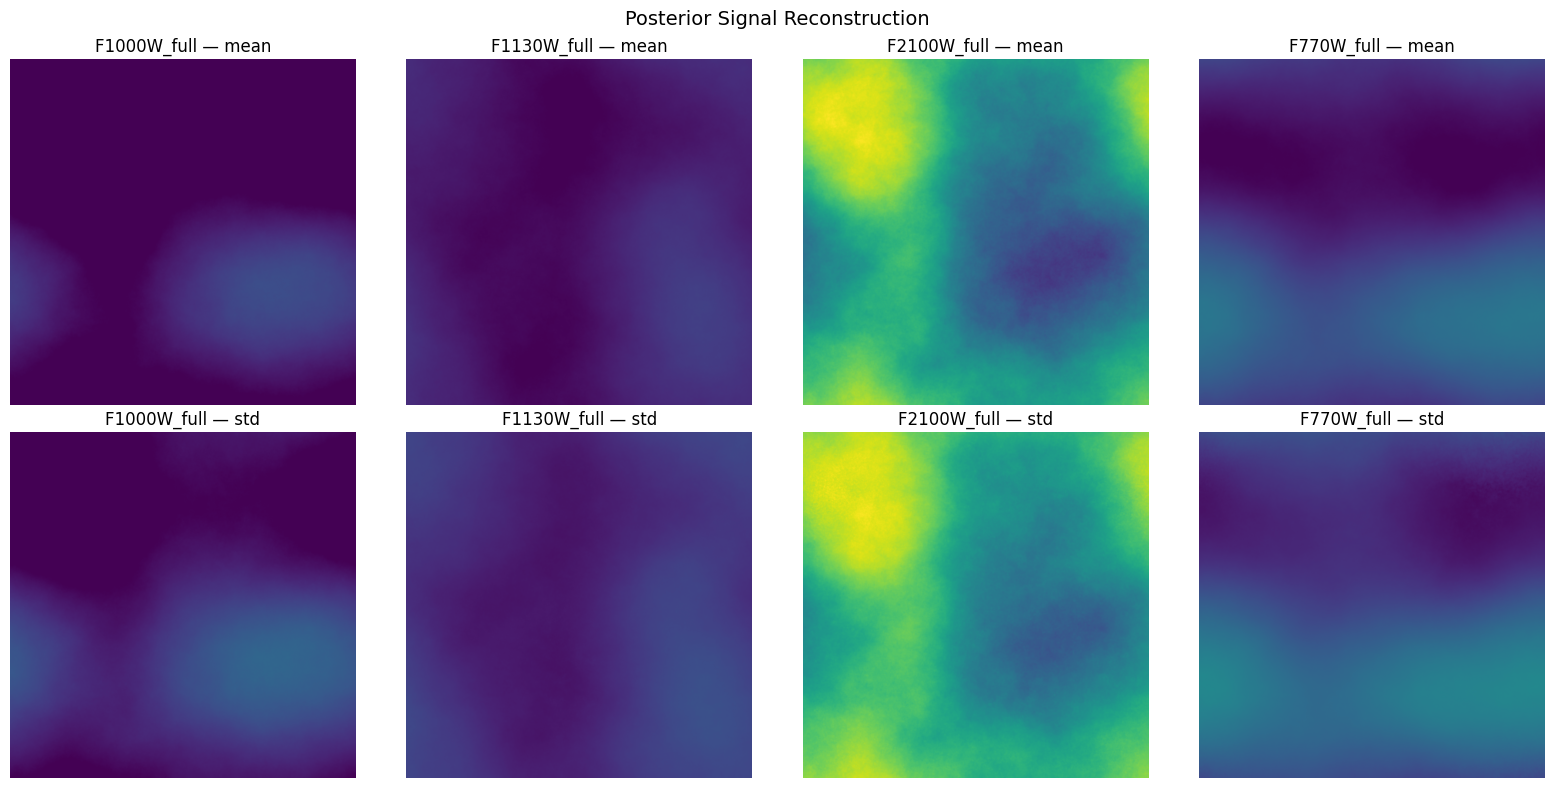

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

channel_keys = result.derived["channel_keys"]
n_channels = result.derived["n_channels"]

fig, axes = plt.subplots(2, n_channels, figsize=(4 * n_channels, 8))

for i in range(n_channels):
    # Mean
    ax = axes[0, i]
    im = ax.imshow(np.array(signal_mean[i]), origin="lower", norm=LogNorm(vmin=1e-2, vmax=signal_mean.max()))
    ax.set_title(f"{channel_keys[i]} — mean")
    ax.axis("off")

    # Std
    ax = axes[1, i]
    im2 = ax.imshow(np.array(signal_std[i]), origin="lower", norm=LogNorm(vmin=1e-3, vmax=signal_std.max()))
    ax.set_title(f"{channel_keys[i]} — std")
    ax.axis("off")

fig.suptitle("Posterior Signal Reconstruction", fontsize=14)
plt.tight_layout()
plt.show()

## Compare reconstructed data to observed data

The signal is the latent sky (before instrument effects). To compare with observations, we need to pass it through the instrument response (reprojection + PSF convolution).

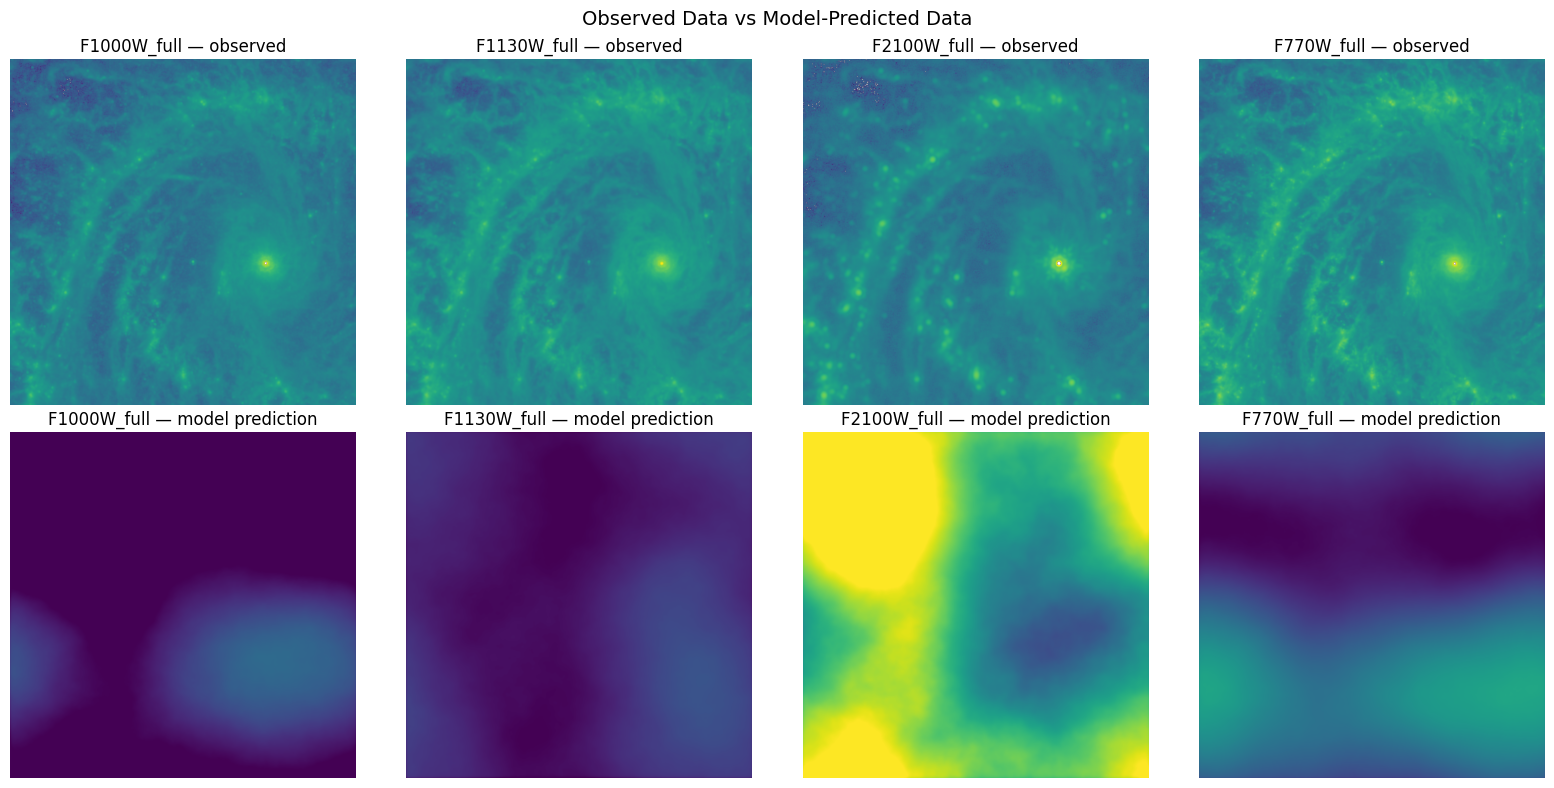

In [14]:
# Predict model data (signal + instrument response) and load observed data
dataset = result.load_dataset()
response_samples = result.predict_response(dataset=dataset)

# Mean of response across samples
import jax.numpy as jnp
response_mean = [
    jnp.mean(jnp.stack([r[i] for r in response_samples]), axis=0)
    for i in range(n_channels)
]

fig, axes = plt.subplots(2, n_channels, figsize=(4 * n_channels, 8))

for i in range(n_channels):
    vmin, vmax = 1e-2, float(np.nanmax(np.array(dataset.data[i])))

    # Observed data
    ax = axes[0, i]
    ax.imshow(np.array(dataset.data[i]), origin="lower", norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.set_title(f"{channel_keys[i]} — observed")
    ax.axis("off")

    # Model-predicted data (after instrument response)
    ax = axes[1, i]
    ax.imshow(np.array(response_mean[i]), origin="lower", norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.set_title(f"{channel_keys[i]} — model prediction")
    ax.axis("off")

fig.suptitle("Observed Data vs Model-Predicted Data", fontsize=14)
plt.tight_layout()
plt.show()

## Individual posterior samples

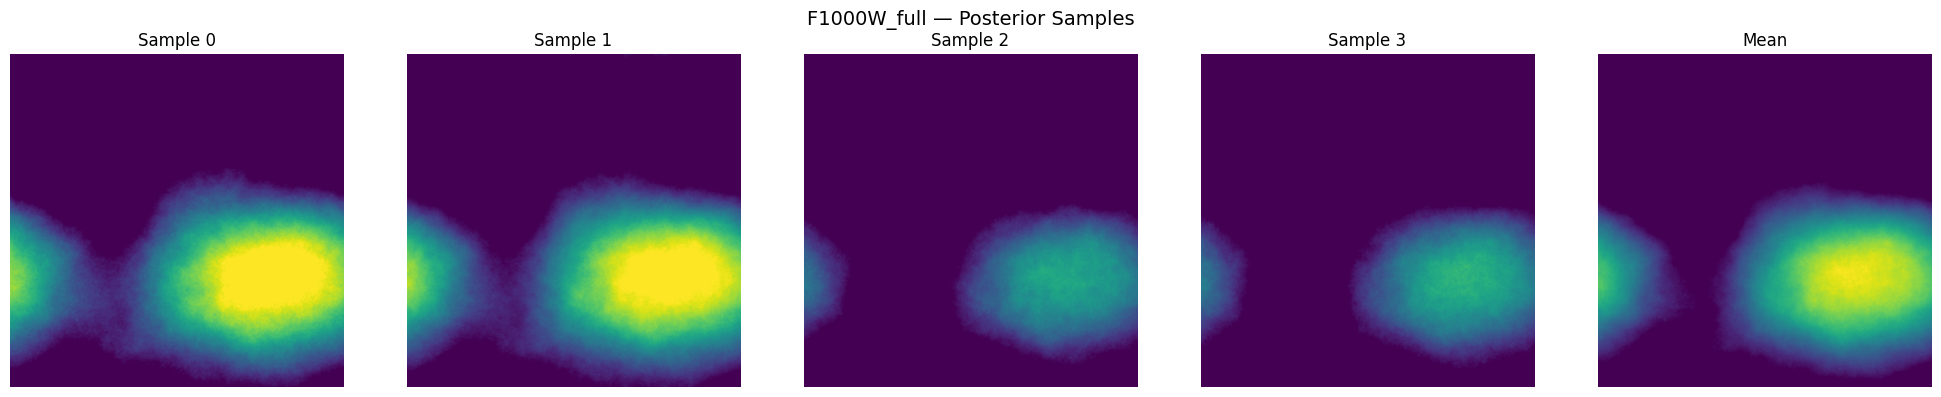

In [15]:
# Show individual samples for channel 0
signals = result.predict_signal()
n_samples = len(signals)

fig, axes = plt.subplots(1, n_samples + 1, figsize=(4 * (n_samples + 1), 4))

ch = 0
vmin, vmax = 1e-2, float(signal_mean[ch].max())

for j, sig in enumerate(signals):
    axes[j].imshow(np.array(sig[ch]), origin="lower", norm=LogNorm(vmin=vmin, vmax=vmax))
    axes[j].set_title(f"Sample {j}")
    axes[j].axis("off")

axes[-1].imshow(np.array(signal_mean[ch]), origin="lower", norm=LogNorm(vmin=vmin, vmax=vmax))
axes[-1].set_title("Mean")
axes[-1].axis("off")

fig.suptitle(f"{channel_keys[ch]} — Posterior Samples", fontsize=14)
plt.tight_layout()
plt.show()